<a href="https://colab.research.google.com/github/emad-host/PD1-Immunotherapy-Bioinformatics-Analysis./blob/main/PD1_Pathway_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gseapy pandas matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 3.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

# إنشاء جدول بيانات تجريبي لتعبير الجينات المرتبطة باستجابة علاج PD-1
data = {
    'Gene_Symbol': ['CD274', 'IFNG', 'CD8A', 'FOXP3', 'PDCD1', 'IL2', 'CTLA4', 'TNF', 'STAT1', 'B2M'],
    'Log2FC': [2.5, 3.1, 2.8, -1.5, 2.2, 1.8, 1.9, 2.0, 2.6, 1.7],
    'P_value': [0.001, 0.0001, 0.0005, 0.03, 0.002, 0.01, 0.004, 0.003, 0.0002, 0.008]
}
df = pd.DataFrame(data)

# فلترة الجينات النشطة
sig_genes = df[(df['Log2FC'] > 1.5) & (df['P_value'] < 0.05)]['Gene_Symbol'].tolist()
print("الجينات النشطة المستهدفة:", sig_genes)

# تحليل المسارات الحيوية
enr = gp.enrichr(gene_list=sig_genes,
                 gene_sets=['KEGG_2021_Human'],
                 organism='human',
                 outdir=None)

# عرض النتائج
print(enr.results[['Term', 'Overlap', 'Adjusted P-value']].head())

الجينات النشطة المستهدفة: ['CD274', 'IFNG', 'CD8A', 'PDCD1', 'IL2', 'CTLA4', 'TNF', 'STAT1', 'B2M']
                                                Term Overlap  Adjusted P-value
0                  T cell receptor signaling pathway   6/104      1.189850e-10
1                         Inflammatory bowel disease    4/65      5.309844e-07
2                Antigen processing and presentation    4/78      7.438726e-07
3  PD-L1 expression and PD-1 checkpoint pathway i...    4/89      9.528741e-07
4                            Cell adhesion molecules   4/148      5.921104e-06


أهم المسارات الحيوية المستخرجة:
                                                Term Overlap  Adjusted P-value
0                  T cell receptor signaling pathway   6/104      1.189850e-10
1                         Inflammatory bowel disease    4/65      5.309844e-07
2                Antigen processing and presentation    4/78      7.438726e-07
3  PD-L1 expression and PD-1 checkpoint pathway i...    4/89      9.528741e-07
4                            Cell adhesion molecules   4/148      5.921104e-06


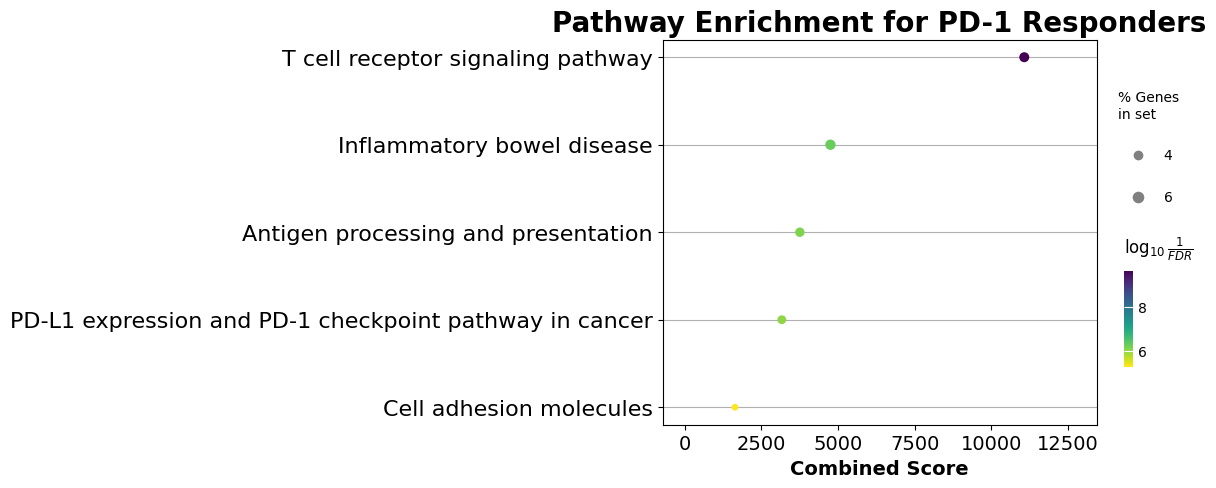

In [3]:
# طباعة أول 5 مسارات حيوية تم اكتشافها
print("أهم المسارات الحيوية المستخرجة:")
print(enr.results[['Term', 'Overlap', 'Adjusted P-value']].head())

# رسم المخطط البياني (Dot plot) للمسارات
gp.dotplot(enr.results,
           title='Pathway Enrichment for PD-1 Responders',
           figsize=(7, 5),
           top_term=5)
plt.show()